In [1]:
from cmf4all import * # SurveyRegistry, differential_cmf, complementary_cmf, fit_power_law
from cmf4all.relations import mass_radius_relation
from cmf4all.plotting import * # plot_mass_radius, plot_differential_cmf, plot_ccdf, plot_slope_posterior, plot_multi_differential_cmf

```python
# customized path
registry = SurveyRegistry.from_directory(
    project_root="./cmf_zoo/",
    metadata_file="data/metadata/surveys.yaml",
)

# default path
registry = SurveyRegistry.from_default()

In [2]:
registry = SurveyRegistry.from_default()

In [3]:
survey = registry.get("CMZ")

In [4]:
print(len(survey.masses()))
print(survey.completeness_msun)

808
0.3


In [5]:
mr = mass_radius_relation(survey)

dcmf = differential_cmf(survey, dlogm=0.2, normalize="area")

ccdf = complementary_cmf(survey)

fit = fit_power_law(
    survey,
    mmin="ks",
    min_tail=30,
    uncertainty="mcmc",
    n_steps=6000,
    burn_in=1000,
)

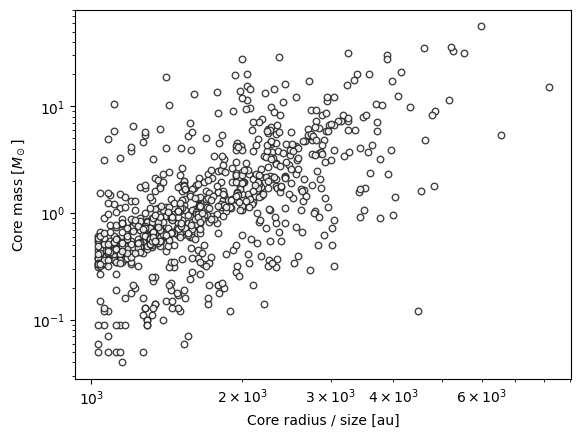

In [6]:
ax = plot_mass_radius(
    survey,
    data_color="#222222",
    marker_facecolor="white",
)

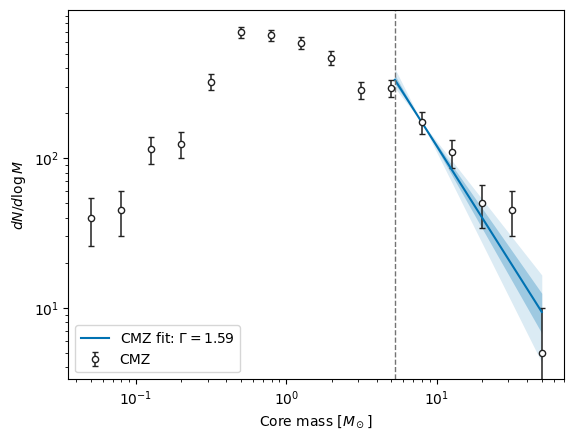

In [7]:
ax, fit = plot_differential_cmf(
    survey,
    # mmin=3.0,
    mmin="ks",
    dlogm=0.20,
    min_tail=30,
    uncertainty="mcmc",
    n_steps=10000,
    burn_in=2000,
)
ax.legend()

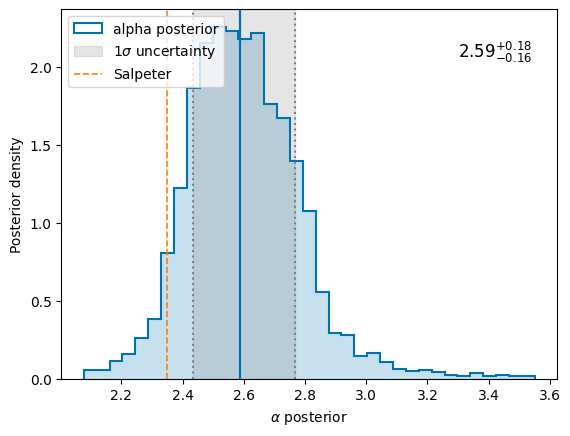

In [8]:
ax2, fit = plot_slope_posterior(
    fit,
    slope="alpha",
    bins=35,
    density=True,
    show_salpeter=True,
)
ax2.legend(loc='upper left')

#### Multi-survey task

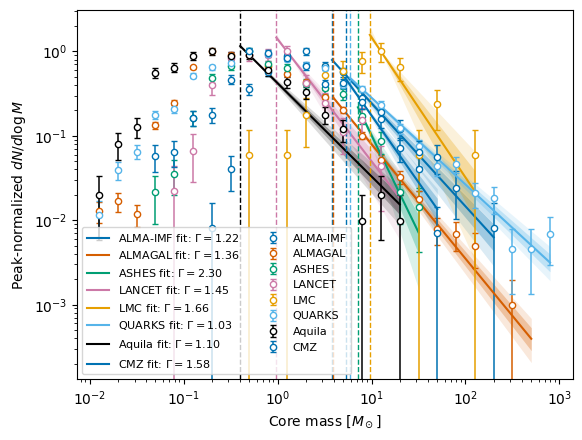

In [9]:
surveys = [
    registry.get("ALMA-IMF"),
    registry.get("ALMAGAL"),
    registry.get("ASHES"),
    registry.get("LANCET"),
    registry.get("LMC"),
    registry.get("QUARKS"),
    registry.get("Aquila"),
    registry.get("CMZ"),
]

ax, results = plot_multi_differential_cmf(
    surveys,
    normalize="peak",
    # normalize="above_mmin",
    # mmin={"ASHES":1.2, "ALMA-IMF":1.64, "ALMAGAL":"ks", "LANCET":"ks", "LMC":8.0, "QUARKS":"ks", "Aquila":1.0, "CMZ":"ks"},
    mmin="ks",
    uncertainty="mcmc", 
    n_steps=10000,
    burn_in=1000,
)

ax.legend(ncols=2, fontsize=8)

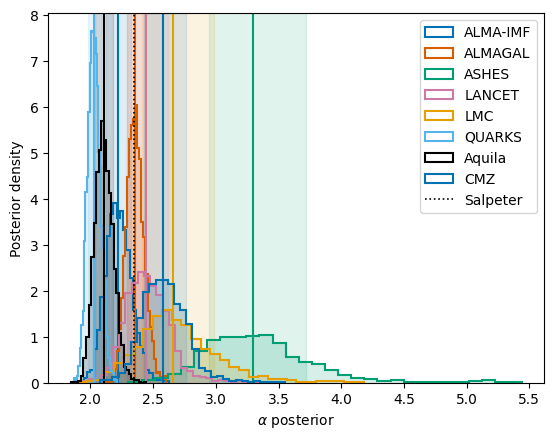

In [10]:
ax2, posterior_results = plot_multi_slope_posterior(
    results,
    slope="alpha",
    show_salpeter=True,
    salpeter_color="k",
    salpeter_linestyle=":"
)
ax2.legend(ncols=1)
# ax2.set_xlim((2.0, 4.0))

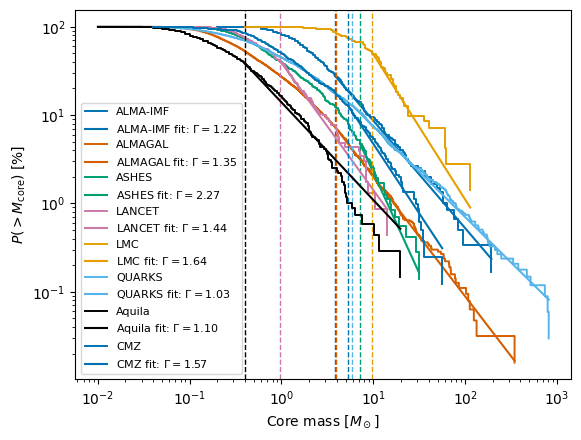

In [11]:
ax, results = plot_multi_ccdf(
    surveys,
    mmin="ks",
    # mmin={"ASHES":1.2, "ALMA-IMF":1.64, "ALMAGAL":"ks", "LANCET":"ks"},
    # labels={"ALMAIMF_all": "ALMA-IMF sample"},
)

ax.legend(ncols=1, fontsize=8)

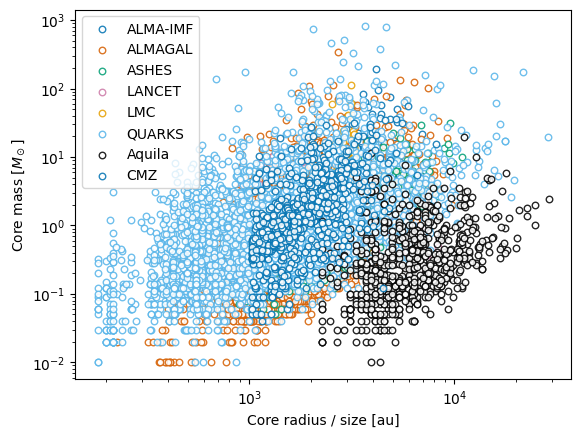

In [12]:
ax, _ = plot_multi_mass_radius(surveys)
ax.legend()

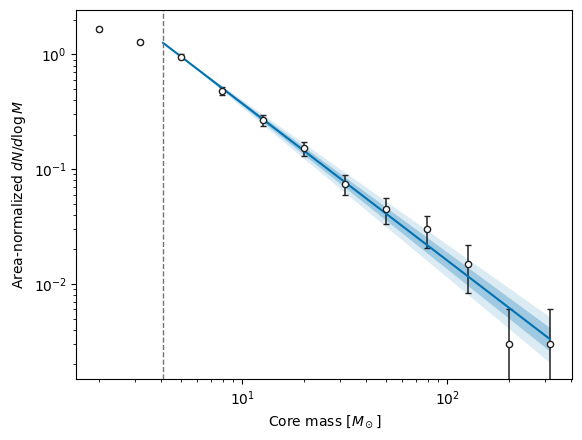

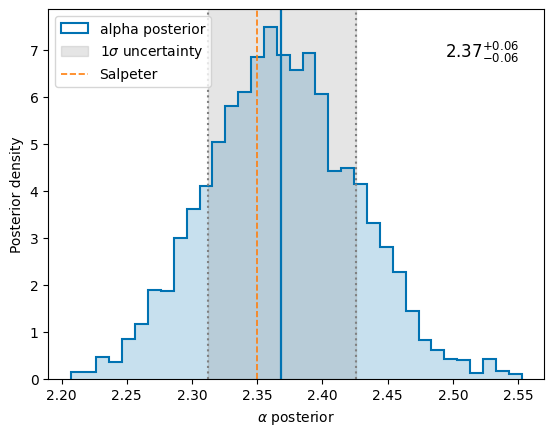

In [29]:
from cmf4all import SurveyRegistry, plot_compiled_differential_cmf, plot_compiled_ccdf

registry = SurveyRegistry.from_default()
surveys = [
    registry.get("ALMA-IMF"),
    registry.get("ALMAGAL"),
    registry.get("ASHES"),
    # registry.get("LANCET"),
    # registry.get("LMC"),
    # registry.get("QUARKS"),
    # registry.get("Aquila"),
    # registry.get("CMZ"),
]

ax, fit = plot_compiled_differential_cmf(
    surveys,
    completeness="shared_max",
    normalize="area",
    mmin="ks",
    uncertainty="mcmc",
)

ax2, fit = plot_slope_posterior(
    fit,
    slope="alpha",
    bins=35,
    density=True,
    show_salpeter=True,
)
ax2.legend(loc='upper left')

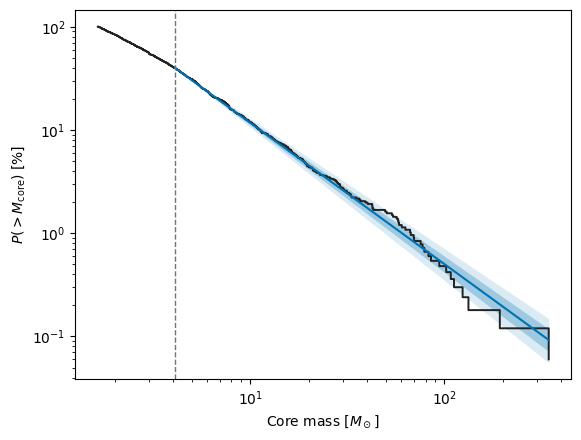

In [30]:
ax3, fit3 = plot_compiled_ccdf(
    surveys,
    completeness="shared_max",
    mmin="ks",
    uncertainty="mcmc",
)